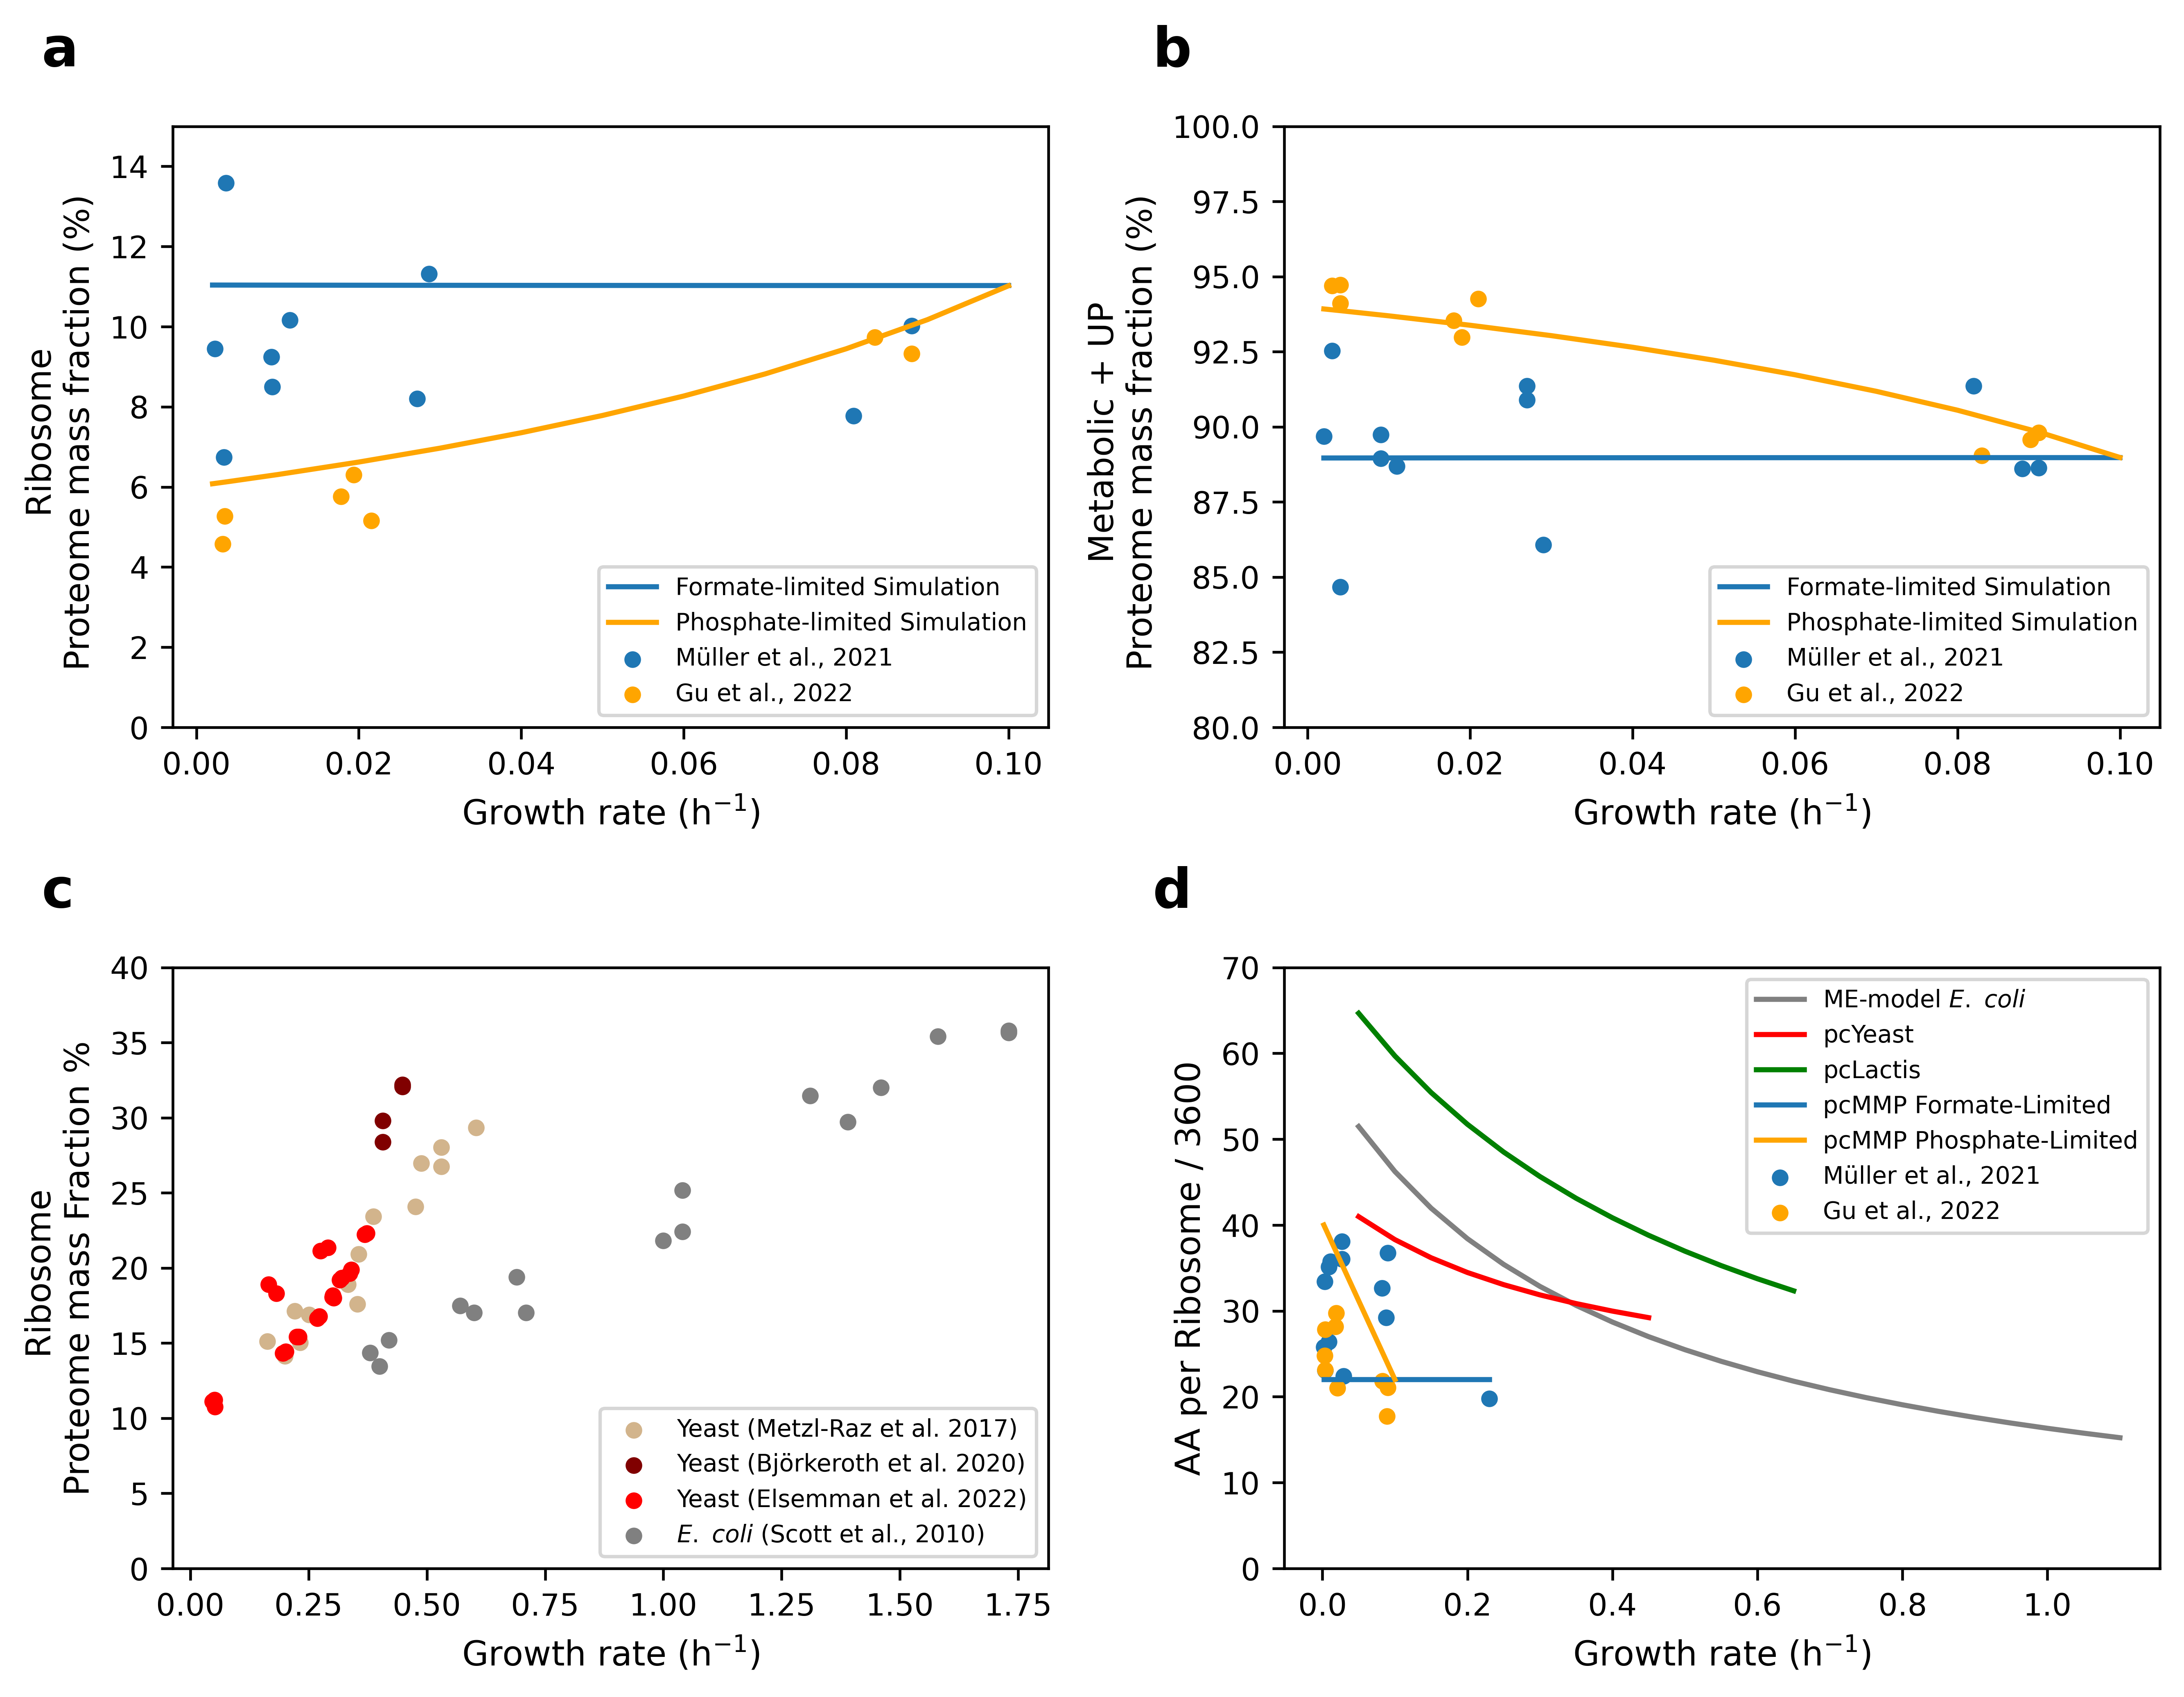

In [1]:
from simulation import Simulation
from extract_fluxes import Fluxes
import matplotlib.pyplot as plt
import  numpy as np
import pandas as pd
def limitation_simulation(limitation_type):
    total_protein_mass=0.6
    up_phosphate_ratio=0.44*total_protein_mass
    up_formate_ratio=0.75*total_protein_mass
    methane_id,formate_id = "R944","R895"
    # closed import H2 ,CO2 , CO ,Aceteta
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
     # objective is phosphate
    if limitation_type == "phosphate":
        sim.set_parameter(model_file='pcMMP.xml', objective="R871", GAM=70, NGAM=1, excel_file='pcMMP.xlsx')
        sim.set_constraint = [f"UP >={up_phosphate_ratio}"]
    # objective is formate 
    elif limitation_type == "formate":
        sim.set_parameter(model_file='pcMMP.xml', objective="R895", GAM=25, NGAM=1, excel_file='pcMMP.xlsx')
        sim.set_constraint = [f"UP >= {up_formate_ratio}"]
    sim.close_reactions(closed_reactions)
    results = {
        "mu_list": [], "metabolic_up_list": [], "ribosome_list": [], "total_proteins": []}
    mus=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    for i, mu in enumerate(mus, start=1):
        if limitation_type == "phosphate":
            y = -183.67*mu + 40.367
            sim.kcat_ribo = y

        sim.file_path = f"output/lp_file_limited_{i}.lp"
        sim.output_file = f"output/output_limited_{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_limited_{i}.lp')
            results["mu_list"].append(mu)
            total_protein = fluxes.extract_reaction_flux("total_protein")
            up = fluxes.extract_reaction_flux("UP")
            results["metabolic_up_list"].append(((up + fluxes.extract_reaction_flux("metaboicMass")) / total_protein)*100)
            results["ribosome_list"].append((fluxes.extract_reaction_flux("ribosome_mass") / total_protein)*100)
            results["total_proteins"].append(total_protein)
            
        else:
            print(f"mu={mu} is not optimal")

    return results

def plot(results_formate,results_phosphate):
    # experiment data from Müller et al., 2021 and Gu et al., 2022
    ribosome_formate_x=[0.003378591, 0.002283602, 0.003677198, 0.009335012, 0.009236709, 0.011536363, 0.080918156, 0.088069874, 0.027194596, 0.028672867]
    ribosome_formate_y=[6.737044289, 9.443378583, 13.58925051, 8.493282875, 9.241842863, 10.16314822, 7.773513233, 10.0191943, 8.205375018, 11.31477965]
    ribosome_phosphate_x=[0.003272973, 0.003487615, 0.021544347, 0.017806336, 0.019380114, 0.083529305, 0.088069874]
    ribosome_phosphate_y=[4.577735363, 5.268714659, 5.153551077, 5.758158235, 6.305182504, 9.73128644, 9.328215001]
    metabolic_up_formate_x= [0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088],
    metabolic_up_formate_y=[92.53326444,89.68149127,84.6638401,89.73814579,88.94636537,88.69243964,90.8952381,91.36403345,86.06815203,88.63525391,91.35786802,88.60987625]
    metabolic_up_phosphate_x= [0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    metabolic_up_phosphate_y=[94.72140762,94.69831643,94.10985305,92.98337479,93.54020768,94.2591956,89.57755165,89.03666427,89.80582524]
    
    #----- Ribosomal Proteome Fraction  Experimental datasets ---
    growth_rate_ribosomal_proteome_Metzl_Yeast=[0.163,0.200,0.232,0.251,0.221,0.333,0.353,0.356,0.387,0.476,0.488,0.531,0.531,0.604]
    ribosomal_proteome_Metzl_Yeast=[15.12328767,14.1369863,15.04109589,16.89041096,17.1369863,18.90410959,17.5890411,20.91780822,23.42465753,24.08219178,26.95890411,26.75342466,28.02739726,29.34246575]

    growth_rate_ribosomal_proteome_Bjoerkeroth_Yeast=[0.407,0.407,0.448,0.448]
    ribosomal_proteome_Bjoerkeroth_Yeast=[28.39304171,29.79327259,32.05416561,32.18959536]

    growth_rate_ribosomal_proteome_Elsemman_Yeast=[0.196,0.202,0.229,0.225,0.268,0.273,0.303,0.302,0.300,0.301,0.316,0.320,0.337,0.340,0.052,0.051,0.048,0.047,0.165,0.182,0.275,0.291,0.369,0.373]
    ribosomal_proteome_Elsemman_Yeast=[14.32188069,14.42730082,15.42067225,15.42423854,16.63448486,16.78347247,18.01020977,18.07018612,18.07051019,18.17539628,19.20237259,19.34112941,19.63435164,19.88213932,10.76953135,11.21205018,11.12355953,11.12079212,18.90970147,18.31688868,21.13308739,21.36339586,22.23945114,22.3070928]

    growth_rate_ribosomal_proteome_ecoli=[0.40,0.57,0.71,1.00,1.31,1.58,0.38,0.60,1.04,1.46,1.73,0.42,0.69,1.04,1.39,1.73]
    ribosomal_proteome_ecoli=[13.452,17.48,17.024,21.811999999999998,31.464,35.416000000000004,14.363999999999999,17.024,22.419999999999998,31.995999999999995,35.644,15.200000000000003,19.38,25.156,29.716000000000005,35.796]
    
    # Experimental datasets AA_per_ribosome-----
    growth_rate_ecoli=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1,1.05,1.1]
    AA_per_ribosome_ecoli=[51.4739229,46.23217923,41.95933457,38.40947547,35.41341654,32.85094067,30.634278,28.69785082,26.99167658,25.47699214,24.12327311,22.9061554,21.80595581,20.80659945,19.8948291,19.05961377,18.29170024,17.58326878,16.92766592,16.31919482,15.75294934,15.22468142]
    
    growth_rate_pcYeast=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45]
    AA_per_ribosome_pcYeast=[40.97588359,38.29813064,36.18227287,34.46824364,33.05150125,31.8608742,30.84623032,29.97123733,29.20892024]
    
    
    growth_rate_pcLactis=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]
    AA_per_ribosome_pcLactis=[64.66666667,59.69230769,55.42857143,51.73333333,48.5,45.64705882,43.11111111,40.84210526,38.8,36.95238095,35.27272727,33.73913043,32.33333333]
    
    growth_rate_pcMMP=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1,0.23]
    AA_per_ribosome_pcMMP=[22,22,22,22,22,22,22,22,22,22,22,22,22,22]
    
    growth_rate_Müller=[0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088,0.23]
    AA_per_ribosome_growth_rate_Müller=[33.41151956,25.77358729,23.06623477,35.12007264,26.42623715,35.77269023,38.10266669,36.05850495,22.37945983,36.77145606,32.6322359,29.22274834,19.8]
    
    growth_rate_Gu=[0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    AA_per_ribosome_Gu=[23.13418804,24.78856424,27.82124245,29.75367158,28.18431084,21.00551668,17.73424637,21.83419724,21.04840967]
    
    growth_rate_pcMMP_phosphate=np.array([0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1])
    AA_per_ribosome_pcMMP_phosphate = -183.67*growth_rate_pcMMP_phosphate + 40.367
    
    plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize":9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7
    })
    fig, axes = plt.subplots(2, 2, figsize=(9, 7), dpi=600)
    ax1, ax2, ax3, ax4 = axes.flatten()
    subplot_labels = ["a", "b", "c", "d"]
    # ---- Ribosome --------------------
    ax1.plot(results_formate["mu_list"], results_formate["ribosome_list"], label="Formate-limited Simulation", color='#1f77b4')
    ax1.plot(results_phosphate["mu_list"], results_phosphate["ribosome_list"], label="Phosphate-limited Simulation", color='orange')
    ax1.scatter(ribosome_formate_x, ribosome_formate_y, color='#1f77b4', s=15, label="Müller et al., 2021")
    ax1.scatter(ribosome_phosphate_x, ribosome_phosphate_y, color='orange', s=15, label="Gu et al., 2022")
    ax1.set_xlabel("Growth rate (h$^{-1}$)")
    ax1.set_ylabel("Ribosome \nProteome mass fraction (%) ")
    ax1.legend(loc='lower right')
   
    ax1.text(-0.15, 1.1, subplot_labels[0], transform=ax1.transAxes,fontsize=16, fontweight='bold')
    ax1.set_ylim(0,15)
    
    
    # ----- metabolic + UP ----------------------
    
    ax2.plot(results_formate["mu_list"], results_formate["metabolic_up_list"], label="Formate-limited Simulation", color='#1f77b4')
    ax2.plot(results_phosphate["mu_list"], results_phosphate["metabolic_up_list"], label="Phosphate-limited Simulation", color='orange')
    ax2.scatter(metabolic_up_formate_x, metabolic_up_formate_y, color='#1f77b4', s=15, label="Müller et al., 2021")
    ax2.scatter(metabolic_up_phosphate_x, metabolic_up_phosphate_y, color='orange', s=15, label="Gu et al., 2022")
    ax2.set_xlabel("Growth rate (h$^{-1}$)")
    ax2.set_ylabel("Metabolic + UP \nProteome mass fraction (%) ")
    ax2.legend(loc='lower right')
    ax2.text(-0.15, 1.1, subplot_labels[1], transform=ax2.transAxes,fontsize=16, fontweight='bold')
    ax2.set_ylim(80,100)
    
    #----- Ribosomal Proteome Fraction from another orgainsms--- 
    ax3.scatter(growth_rate_ribosomal_proteome_Metzl_Yeast, ribosomal_proteome_Metzl_Yeast, label="Yeast (Metzl-Raz et al. 2017)",s=15,color='Tan')
    ax3.scatter(growth_rate_ribosomal_proteome_Bjoerkeroth_Yeast, ribosomal_proteome_Bjoerkeroth_Yeast, label="Yeast (Björkeroth et al. 2020)",s=15,color='Maroon')
    ax3.scatter(growth_rate_ribosomal_proteome_Elsemman_Yeast, ribosomal_proteome_Elsemman_Yeast, label="Yeast (Elsemman et al. 2022)",s=15,color='red')
    ax3.scatter(growth_rate_ribosomal_proteome_ecoli,ribosomal_proteome_ecoli,label=r"$\it{E.\ coli}$ (Scott et al., 2010)",s=15,color='gray')
    ax3.set_xlabel("Growth rate (h$^{-1}$)")
    ax3.set_ylabel("Ribosome \nProteome mass Fraction %")
    ax3.legend(loc='lower right')

    ax3.text(-0.15, 1.1, subplot_labels[2], transform=ax3.transAxes,fontsize=16, fontweight='bold')
    ax3.set_ylim(0,40)
    
    # ---- AA per ribosome ----
    ax4.plot(growth_rate_ecoli, AA_per_ribosome_ecoli, label=r"ME-model $\it{E.\ coli}$",color='gray' )
    ax4.plot(growth_rate_pcYeast, AA_per_ribosome_pcYeast, label="pcYeast",color='red')
    ax4.plot(growth_rate_pcLactis, AA_per_ribosome_pcLactis, label="pcLactis",color='green')
    ax4.plot(growth_rate_pcMMP, AA_per_ribosome_pcMMP, label="pcMMP Formate-Limited", color='#1f77b4')
    ax4.plot(growth_rate_pcMMP_phosphate, AA_per_ribosome_pcMMP_phosphate, label="pcMMP Phosphate-Limited", color='orange')
    ax4.scatter(growth_rate_Müller,AA_per_ribosome_growth_rate_Müller,label="Müller et al., 2021",s=15, color='#1f77b4')
    ax4.scatter(growth_rate_Gu,AA_per_ribosome_Gu,label="Gu et al., 2022",s=15, color='orange')
    ax4.set_xlabel("Growth rate (h$^{-1}$)")
    ax4.set_ylabel("AA per Ribosome / 3600")
    ax4.legend()
    ax4.set_ylim(0,70)
    ax4.text(-0.15, 1.1, subplot_labels[3], transform=ax4.transAxes,fontsize=16, fontweight='bold')
    plt.subplots_adjust(wspace=0.4, hspace=0.3)
    plt.savefig("Figures/Ribosomal_Proteome_Fraction_Comparsion_and_metabolic_UP.png", dpi=300)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    results_phosphate = limitation_simulation(limitation_type="phosphate")
    
    results_formate = limitation_simulation(limitation_type="formate")
    plot(results_formate,results_phosphate)
    